# **Sistem Deteksi Banjir Menggunakan Stacked Bidirectional LSTM**

---
  
**Metodologi:** Deep Learning (LSTM) dengan Strict Temporal Split  
**Target:** Klasifikasi Status Banjir (Aman, Siaga, Bahaya)

---

## **Pendahuluan**
Notebook ini berisi pipeline lengkap untuk membangun model deteksi dini banjir menggunakan data *time-series*. Kita akan menggunakan arsitektur **Stacked Bidirectional Long Short-Term Memory (LSTM)** yang mampu menangkap pola ketergantungan temporal jangka panjang dan pendek dari dua arah (masa lalu ke masa depan dan sebaliknya).

### **Daftar Isi:**
1. **Persiapan Environment** (Mount Drive & Folder Structure)
2. **Load Dataset**
3. **Exploratory Data Analysis (EDA)**
4. **Data Preprocessing & Cleaning**
5. **Feature Engineering** (Lag, Rolling, Velocity, Acceleration)
6. **Label Encoding & Scaling**
7. **Sequence Creation** (Sliding Window)
8. **Strict Temporal Splitting**
9. **Model Building & Training**
10. **Evaluasi Klasifikasi & Analisis Regresi**
11. **Visualisasi Hasil & Analisis False Negative**
12. **Export Model & Artefak**

## **STEP 1 — Mount Google Drive & Folder Setup**
Langkah pertama adalah menghubungkan notebook ini ke Google Drive dan menyiapkan struktur folder agar semua hasil (model, grafik, laporan) tersimpan secara permanen.

In [1]:
import os
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Definisikan Base Directory
BASE_DIR = "/content/drive/MyDrive/flood-detection-lstm"

# 3. List folder yang diperlukan
folders = [
    'models', 'scalers', 'encoders',
    'reports', 'plots', 'logs',
]

for folder in folders:
    path = os.path.join(BASE_DIR, folder)
    if not os.path.exists(path):
        os.makedirs(path)
        print(f"Folder dibuat: {path}")
    else:
        print(f"Folder sudah ada: {path}")

print("\nPersiapan folder selesai!")

Mounted at /content/drive
Folder dibuat: /content/drive/MyDrive/flood-detection-lstm/models
Folder dibuat: /content/drive/MyDrive/flood-detection-lstm/scalers
Folder dibuat: /content/drive/MyDrive/flood-detection-lstm/encoders
Folder dibuat: /content/drive/MyDrive/flood-detection-lstm/reports
Folder dibuat: /content/drive/MyDrive/flood-detection-lstm/plots
Folder dibuat: /content/drive/MyDrive/flood-detection-lstm/logs

Persiapan folder selesai!


## **STEP 2 — Import Libraries**
Kita akan menggunakan `pandas` dan `numpy` untuk manipulasi data, `matplotlib` dan `seaborn` untuk visualisasi, serta `tensorflow`/`keras` untuk membangun model deep learning.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
from datetime import datetime

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score, roc_curve, auc,
    precision_recall_curve, mean_squared_error, mean_absolute_error
)

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

import warnings
warnings.filterwarnings('ignore')

print("TensorFlow Version:", tf.__version__)
print("Libraries imported successfully.")

TensorFlow Version: 2.20.0
Libraries imported successfully.


## **STEP 3 — Load Dataset**
Kita memuat dataset dari Google Drive. Dataset ini berisi riwayat tinggi air per jam dari Januari hingga Juni 2025.

In [3]:
# Sesuaikan nama file dengan dataset yang Anda miliki di folder data
DATA_PATH = os.path.join(BASE_DIR, "dataset/flood_dataset_2025.csv")

if not os.path.exists(DATA_PATH):
    print(f"[ERROR] File tidak ditemukan di: {DATA_PATH}")
    print("Pastikan Anda sudah mengupload dataset ke folder tersebut.")
else:
    df = pd.read_csv(DATA_PATH)
    print(f"Dataset berhasil dimuat. Total rows: {len(df)}")

Dataset berhasil dimuat. Total rows: 4344


## **STEP 4 — Exploratory Data Analysis (EDA)**
Sebelum membangun model, kita harus memahami karakteristik data. Kita akan melihat distribusi status (Aman, Siaga, Bahaya) dan pola pergerakan air.

--- Data Preview ---


,Datetime,Date,Time,Tinggi_Air,Delta_Tinggi,Rolling_Mean,Status
0,2025-01-01 00:00:00,2025-01-01,00:00:00,2.51,0.00,2.51,Aman
1,2025-01-01 01:00:00,2025-01-01,01:00:00,2.52,0.01,2.51,Aman
2,2025-01-01 02:00:00,2025-01-01,02:00:00,2.57,0.05,2.53,Aman
3,2025-01-01 03:00:00,2025-01-01,03:00:00,2.58,0.01,2.54,Aman
4,2025-01-01 04:00:00,2025-01-01,04:00:00,2.61,0.03,2.56,Aman



--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4344 entries, 0 to 4343
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Datetime      4344 non-null   object 
 1   Date          4344 non-null   object 
 2   Time          4344 non-null   object 
 3   Tinggi_Air    4344 non-null   float64
 4   Delta_Tinggi  4344 non-null   float64
 5   Rolling_Mean  4344 non-null   float64
 6   Status        4344 non-null   object 
dtypes: float64(3), object(4)
memory usage: 237.7+ KB

--- Missing Values ---
Datetime        0
Date            0
Time            0
Tinggi_Air      0
Delta_Tinggi    0
Rolling_Mean    0
Status          0
dtype: int64

--- Label Distribution ---
Status
Aman      2742
Siaga      874
Bahaya     728
Name: count, dtype: int64
Status
Aman      63.121547
Siaga     20.119705
Bahaya    16.758748
Name: proportion, dtype: float64


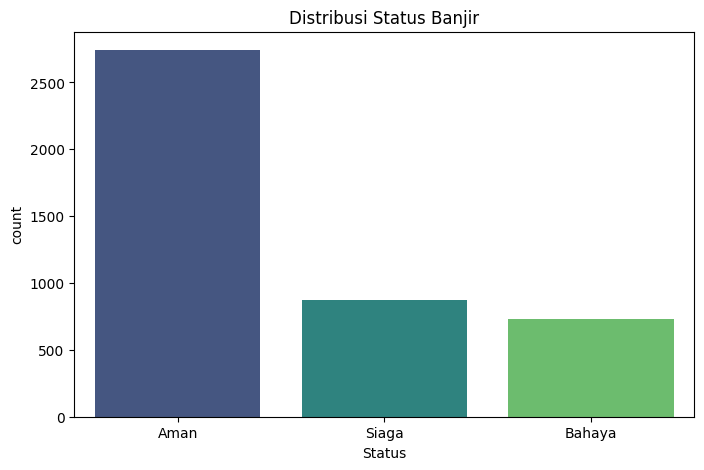

In [4]:
print("--- Data Preview ---")
display(df.head())

print("\n--- Dataset Info ---")
df.info()

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Label Distribution ---")
print(df['Status'].value_counts())
print(df['Status'].value_counts(normalize=True) * 100)

# Visualisasi Distribusi
plt.figure(figsize=(8, 5))
sns.countplot(x='Status', data=df, palette='viridis', order=['Aman', 'Siaga', 'Bahaya'])
plt.title('Distribusi Status Banjir')
plt.savefig(os.path.join(BASE_DIR, 'plots/distribusi_label.png'))
plt.show()

### **Visualisasi Timeline**
Melihat bagaimana tinggi air berubah seiring waktu.

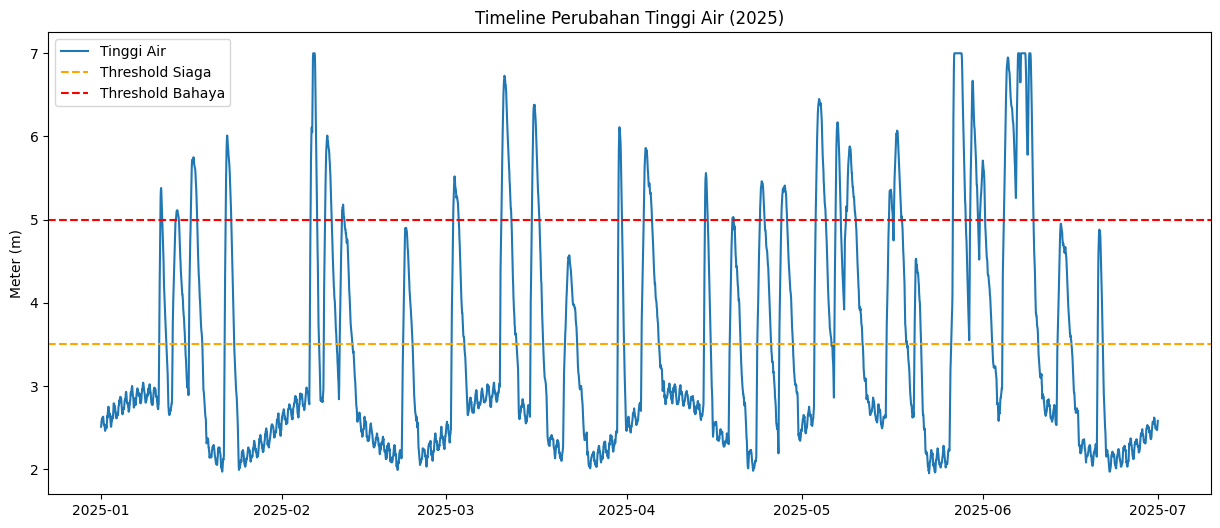

In [5]:
df['Datetime'] = pd.to_datetime(df['Datetime'])

plt.figure(figsize=(15, 6))
plt.plot(df['Datetime'], df['Tinggi_Air'], label='Tinggi Air', color='tab:blue')
plt.axhline(y=3.5, color='orange', linestyle='--', label='Threshold Siaga')
plt.axhline(y=5.0, color='red', linestyle='--', label='Threshold Bahaya')
plt.title('Timeline Perubahan Tinggi Air (2025)')
plt.ylabel('Meter (m)')
plt.legend()
plt.savefig(os.path.join(BASE_DIR, 'plots/timeline_tinggi_air.png'))
plt.show()

## **STEP 5 — Data Cleaning**
Memastikan data terurut secara kronologis dan tidak ada duplikat yang mengganggu pola *time-series*.

In [6]:
# 1. Sort by Datetime
df = df.sort_values('Datetime').reset_index(drop=True)

# 2. Remove Duplicates
df = df.drop_duplicates(subset=['Datetime'])

# 3. Handle Missing Values (jika ada)
df['Tinggi_Air'] = df['Tinggi_Air'].interpolate(method='linear')

print(f"Cleaning selesai. Baris tersisa: {len(df)}")

Cleaning selesai. Baris tersisa: 4344


## **STEP 6 — Feature Engineering**
Deep Learning seringkali membutuhkan fitur tambahan untuk menangkap dinamika sistem.
- **Lag**: Nilai sebelumnya (sangat penting untuk forecasting).
- **Rolling Mean/Std**: Tren rata-rata dan volatilitas.
- **Velocity**: Kecepatan perubahan (`diff`).
- **Acceleration**: Perubahan dari kecepatan.

In [7]:
def apply_feature_engineering(data):
    d = data.copy()

    # 1. Rolling Features
    d['Rolling_Mean_6'] = d['Tinggi_Air'].rolling(window=6).mean()
    d['Rolling_Std_6'] = d['Tinggi_Air'].rolling(window=6).std()

    # 2. Lag Features (1h, 2h, 3h back)
    d['Lag_1'] = d['Tinggi_Air'].shift(1)
    d['Lag_2'] = d['Tinggi_Air'].shift(2)

    # 3. Velocity (Delta)
    d['Velocity'] = d['Tinggi_Air'].diff()

    # 4. Acceleration
    d['Acceleration'] = d['Velocity'].diff()

    # Drop rows dengan NaN akibat rolling/lag
    d = d.dropna().reset_index(drop=True)
    return d

df_engineered = apply_feature_engineering(df)
print(f"Feature Engineering selesai. Total fitur: {df_engineered.shape[1]}")
df_engineered.head()

Feature Engineering selesai. Total fitur: 13


,Datetime,Date,Time,Tinggi_Air,Delta_Tinggi,Rolling_Mean,Status,Rolling_Mean_6,Rolling_Std_6,Lag_1,Lag_2,Velocity,Acceleration
0,2025-01-01 05:00:00,2025-01-01,05:00:00,2.61,0.00,2.58,Aman,2.566667,0.043205,2.61,2.58,0.00,-0.03
1,2025-01-01 06:00:00,2025-01-01,06:00:00,2.59,-0.02,2.59,Aman,2.580000,0.033466,2.61,2.61,-0.02,-0.02
2,2025-01-01 07:00:00,2025-01-01,07:00:00,2.60,0.01,2.60,Aman,2.593333,0.016330,2.59,2.61,0.01,0.03
3,2025-01-01 08:00:00,2025-01-01,08:00:00,2.63,0.03,2.61,Aman,2.603333,0.017512,2.60,2.59,0.03,0.02
4,2025-01-01 09:00:00,2025-01-01,09:00:00,2.63,0.00,2.61,Aman,2.611667,0.016021,2.63,2.60,0.00,-0.03


## **STEP 7 — Label Encoding**
Mengubah label teks (Aman, Siaga, Bahaya) menjadi angka (0, 1, 2).

In [8]:
le = LabelEncoder()
df_engineered['Status_Encoded'] = le.fit_transform(df_engineered['Status'])

# Simpan encoder
joblib.dump(le, os.path.join(BASE_DIR, 'encoders/label_encoder.joblib'))
joblib.dump(le, os.path.join(BASE_DIR, 'encoders/label_encoder.pkl'))

mapping = dict(zip(le.classes_, range(len(le.classes_))))
print("Label Mapping:", mapping)

Label Mapping: {'Aman': 0, 'Bahaya': 1, 'Siaga': 2}


## **STEP 8 — Strict Temporal Split**
Dalam data *time-series*, kita **TIDAK BOLEH** menggunakan `train_test_split` acak (shuffle). Kita harus membagi data berdasarkan urutan waktu untuk menghindari *Data Leakage* (model melihat masa depan untuk memprediksi masa lalu).

In [9]:
n = len(df_engineered)
train_size = int(n * 0.7)
val_size = int(n * 0.15)
test_size = n - train_size - val_size

train_df = df_engineered.iloc[:train_size]
val_df = df_engineered.iloc[train_size:train_size+val_size]
test_df = df_engineered.iloc[train_size+val_size:]

print(f"Train set: {len(train_df)}")
print(f"Validation set: {len(val_df)}")
print(f"Test set: {len(test_df)}")

Train set: 3037
Validation set: 650
Test set: 652


## **STEP 9 — Feature Scaling**
Model LSTM sangat sensitif terhadap skala data. Kita gunakan `MinMaxScaler` untuk menormalkan fitur ke rentang [0, 1].

**Aturan Penting:** `fit` hanya pada Training Set, lalu `transform` pada Validation dan Test Set.

In [10]:
features_to_scale = [
    'Tinggi_Air', 'Delta_Tinggi', 'Rolling_Mean_6', 'Rolling_Std_6',
    'Lag_1', 'Lag_2', 'Velocity', 'Acceleration'
]

scaler = MinMaxScaler()
scaler.fit(train_df[features_to_scale])

# Simpan scaler
joblib.dump(scaler, os.path.join(BASE_DIR, 'scalers/minmax_scaler.joblib'))
joblib.dump(scaler, os.path.join(BASE_DIR, 'scalers/minmax_scaler.pkl'))

train_scaled = scaler.transform(train_df[features_to_scale])
val_scaled = scaler.transform(val_df[features_to_scale])
test_scaled = scaler.transform(test_df[features_to_scale])

## **STEP 10 — Sequence Creation (Sliding Window)**
LSTM membutuhkan data dalam bentuk 3D tensor: `(samples, timesteps, features)`.
Kita akan menggunakan data 24 jam terakhir untuk memprediksi status jam berikutnya.

In [11]:
TIMESTEP = 24 # 24 jam terakhir

def create_sequences(features, target, timestep):
    X, y = [], []
    for i in range(len(features) - timestep):
        X.append(features[i:(i + timestep)])
        y.append(target[i + timestep])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled, train_df['Status_Encoded'].values, TIMESTEP)
X_val, y_val = create_sequences(val_scaled, val_df['Status_Encoded'].values, TIMESTEP)
X_test, y_test = create_sequences(test_scaled, test_df['Status_Encoded'].values, TIMESTEP)

print("Shape X_train:", X_train.shape)
print("Shape y_train:", y_train.shape)

Shape X_train: (3013, 24, 8)
Shape y_train: (3013,)


## **STEP 11 — Model Building: Stacked Bidirectional LSTM**
Arsitektur ini menggabungkan dua lapisan LSTM yang bekerja dua arah (Bidirectional) untuk menangkap konteks temporal yang lebih kaya.

In [12]:
model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    Bidirectional(LSTM(128, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(64)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 24, 256)        │       140,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 308,867 (1.18 MB)

 Trainable params: 308,867 (1.18 MB)

 Non-trainable params: 0 (0.00 B)

### **Training dengan Callbacks**
- `EarlyStopping`: Berhenti jika tidak ada perbaikan agar tidak *overfitting*.
- `ModelCheckpoint`: Menyimpan model terbaik secara otomatis.

In [13]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5),
    ModelCheckpoint(os.path.join(BASE_DIR, 'models/best_lstm_model.keras'), save_best_only=True)
]

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 21s 140ms/step - accuracy: 0.8294 - loss: 0.4539 - val_accuracy: 0.9233 - val_loss: 0.2476 - learning_rate: 0.0010
Epoch 2/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 11s 111ms/step - accuracy: 0.9190 - loss: 0.2245 - val_accuracy: 0.8802 - val_loss: 0.2875 - learning_rate: 0.0010
Epoch 3/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 12s 123ms/step - accuracy: 0.9406 - loss: 0.1759 - val_accuracy: 0.9185 - val_loss: 0.2206 - learning_rate: 0.0010
Epoch 4/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 13s 134ms/step - accuracy: 0.9469 - loss: 0.1539 - val_accuracy: 0.9505 - val_loss: 0.1567 - learning_rate: 0.0010
Epoch 5/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 13s 133ms/step - accuracy: 0.9545 - loss: 0.1435 - val_accuracy: 0.9281 - val_loss: 0.1775 - learning_rate: 0.0010
Epoch 6/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 11s 120ms/step - accuracy: 0.9472 - loss: 0.1544 - val_accuracy: 0.8387 - val_loss: 0.4018 - learning_rate: 0.0010
Epoch 7/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 11s 114ms/step - accuracy: 0.9575 - loss: 0.

## **STEP 12 — Evaluation & Performance Analysis**
Kita akan mengevaluasi seberapa baik model memprediksi status banjir pada data Test Set yang belum pernah dilihat sebelumnya.

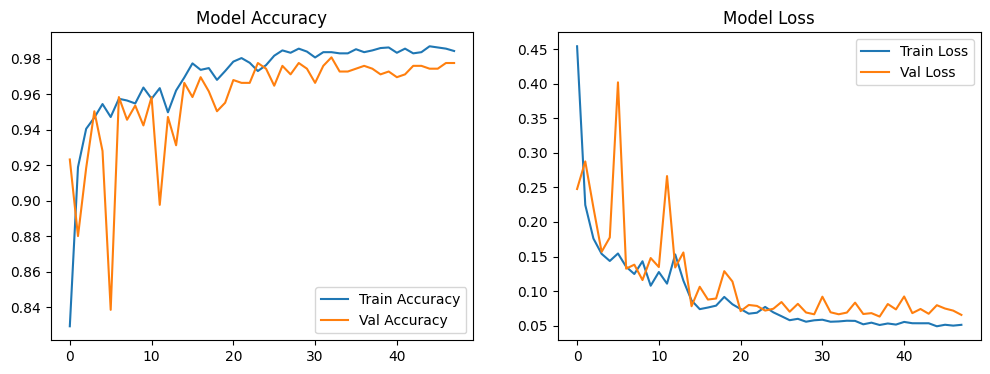

In [14]:
# Plot History
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.legend()
plt.savefig(os.path.join(BASE_DIR, 'plots/training_history.png'))
plt.show()

### **Classification Report & Confusion Matrix**

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step

--- Classification Report ---
              precision    recall  f1-score   support

        Aman       1.00      0.99      0.99       409
      Bahaya       0.94      0.99      0.97       117
       Siaga       0.94      0.93      0.94       102

    accuracy                           0.98       628
   macro avg       0.96      0.97      0.97       628
weighted avg       0.98      0.98      0.98       628



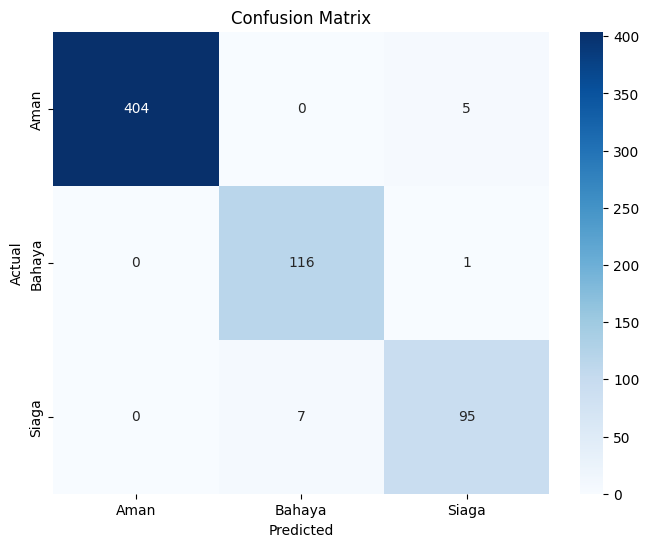

In [15]:
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig(os.path.join(BASE_DIR, 'plots/confusion_matrix.png'))
plt.show()

## **STEP 13 — Regression-like Error Analysis**
Meskipun ini adalah masalah klasifikasi, kita bisa mengukur "jarak" kesalahan antara label asli dan prediksi untuk melihat seberapa jauh penyimpangannya.

In [16]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / (y_test + 1e-10))) * 100

print(f"RMSE: {rmse:.4f} (Mengukur besarnya deviasi kesalahan label)")
print(f"MAE: {mae:.4f} (Rata-rata kesalahan absolut langkah label)")
print(f"MAPE: {mape:.2f}% (Rata-rata persentase kesalahan label)")

RMSE: 0.2112 (Mengukur besarnya deviasi kesalahan label)
MAE: 0.0287 (Rata-rata kesalahan absolut langkah label)
MAPE: 15923566879.70% (Rata-rata persentase kesalahan label)


## **STEP 14 — Advanced Flood Analysis**
### **False Negative Analysis (Potensi Bahaya Tidak Terdeteksi)**
Analisis ini sangat krusial untuk Early Warning System.

In [17]:
fn_indices = np.where((y_test == 2) & (y_pred < 2))[0]
print(f"Total Kejadian 'Bahaya' yang gagal dideteksi: {len(fn_indices)}")

if len(fn_indices) > 0:
    print("Contoh index kegagalan:", fn_indices[:5])

Total Kejadian 'Bahaya' yang gagal dideteksi: 7
Contoh index kegagalan: [228 229 230 231 386]


### **Visualisasi Prediksi vs Aktual pada Timeline**

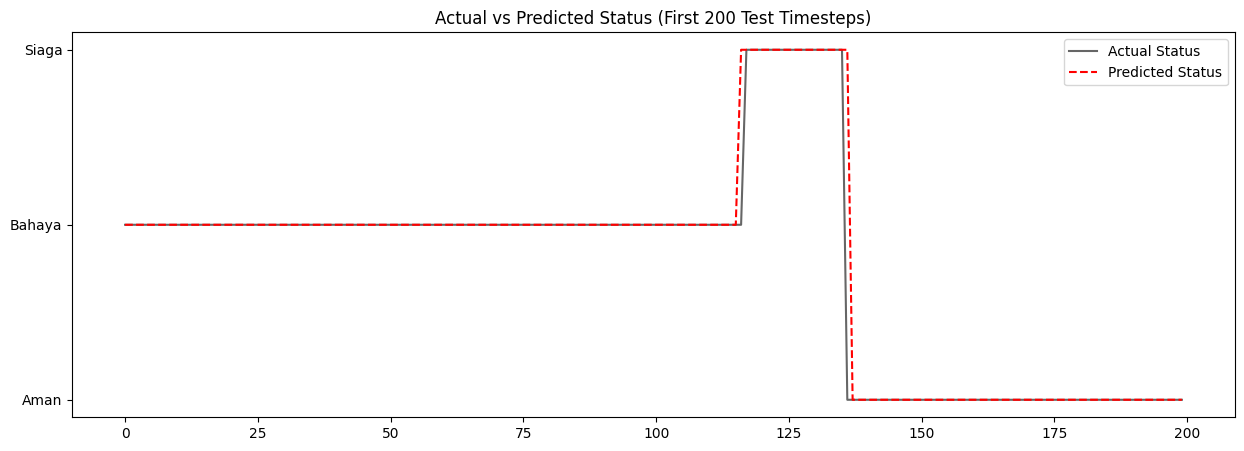

In [18]:
plt.figure(figsize=(15, 5))
plt.plot(y_test[:200], label='Actual Status', color='black', alpha=0.6)
plt.plot(y_pred[:200], label='Predicted Status', color='red', linestyle='--')
plt.title('Actual vs Predicted Status (First 200 Test Timesteps)')
plt.yticks([0, 1, 2], le.classes_)
plt.legend()
plt.savefig(os.path.join(BASE_DIR, 'plots/prediction_timeline.png'))
plt.show()

## **STEP 15 — Save Artifacts & Report Generation**
Langkah terakhir adalah menyimpan model final dan membuat laporan ringkas.

In [19]:
model.save(os.path.join(BASE_DIR, 'models/final_lstm_model.keras'))

report = {
    'accuracy': accuracy_score(y_test, y_pred),
    'f1_macro': f1_score(y_test, y_pred, average='macro'),
    'rmse': float(rmse),
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
}

with open(os.path.join(BASE_DIR, 'reports/final_report.md'), 'w') as f:
    f.write("# HASIL EVALUASI MODEL LSTM DETEKSI BANJIR\n\n")
    f.write(f"- **Accuracy**: {report['accuracy']:.4f}\n")
    f.write(f"- **F1-Score (Macro)**: {report['f1_macro']:.4f}\n")
    f.write(f"- **RMSE**: {report['rmse']:.4f}\n")
    f.write(f"- **Waktu Eksekusi**: {report['timestamp']}\n\n")
    f.write("## Kesimpulan\n")
    f.write("Model ini telah dilatih dengan strict temporal splitting untuk menghindari kebocoran data. ")
    f.write("Arsitektur Bidirectional LSTM membantu menangkap tren kenaikan air sebelum mencapai status bahaya.")

print("Pipeline selesai! Seluruh output tersimpan di Google Drive.")

Pipeline selesai! Seluruh output tersimpan di Google Drive.


## **STEP 16 — Make Predictions with the Saved Model**

Now that the model is trained and saved, we can load it and use it to make predictions on new, unseen data (or in this case, the `X_test` data as an example).

In [20]:
loaded_model = load_model(os.path.join(BASE_DIR, 'models/best_lstm_model.keras'))

# Make predictions on the test set
y_pred_prob_loaded = loaded_model.predict(X_test)
y_pred_loaded = np.argmax(y_pred_prob_loaded, axis=1)

print("Predicted labels (first 20):")
print(y_pred_loaded[:20])
print("\nActual labels (first 20):")
print(y_test[:20])

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step
Predicted labels (first 20):
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]

Actual labels (first 20):
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


### **Interpretasi Prediksi**

Model mengeluarkan angka-angka yang merupakan representasi dari label asli ('Aman', 'Siaga', 'Bahaya'). Kita bisa mengubah angka-angka ini kembali ke label aslinya menggunakan `inverse_transform` dari `LabelEncoder` yang sudah disimpan.

In [21]:
loaded_le = joblib.load(os.path.join(BASE_DIR, 'encoders/label_encoder.pkl'))

# Inverse transform the predicted and actual labels to their original string format
y_pred_original = loaded_le.inverse_transform(y_pred_loaded)
y_test_original = loaded_le.inverse_transform(y_test)

print("Predicted Status (first 20):")
print(y_pred_original[:20])
print("\nActual Status (first 20):")
print(y_test_original[:20])

Predicted Status (first 20):
['Bahaya' 'Bahaya' 'Bahaya' 'Bahaya' 'Bahaya' 'Bahaya' 'Bahaya' 'Bahaya'
 'Bahaya' 'Bahaya' 'Bahaya' 'Bahaya' 'Bahaya' 'Bahaya' 'Bahaya' 'Bahaya'
 'Bahaya' 'Bahaya' 'Bahaya' 'Bahaya']

Actual Status (first 20):
['Bahaya' 'Bahaya' 'Bahaya' 'Bahaya' 'Bahaya' 'Bahaya' 'Bahaya' 'Bahaya'
 'Bahaya' 'Bahaya' 'Bahaya' 'Bahaya' 'Bahaya' 'Bahaya' 'Bahaya' 'Bahaya'
 'Bahaya' 'Bahaya' 'Bahaya' 'Bahaya']


### **Confusion Matrix Evaluation**

To better understand the model's performance, we can visualize the confusion matrix which shows where the model is making correct predictions and where it is getting confused between classes.

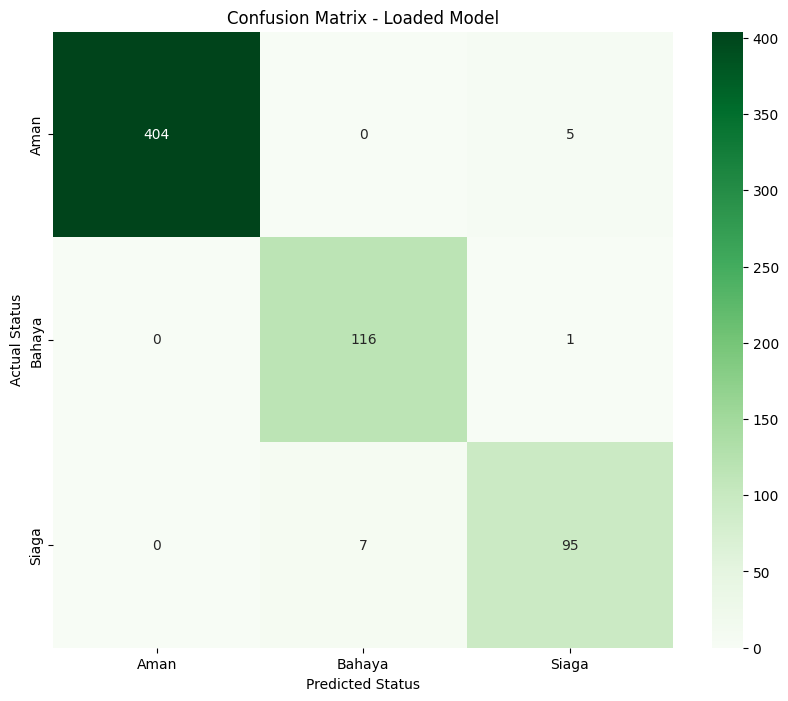

In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute confusion matrix using the loaded model's predictions
cm_loaded = confusion_matrix(y_test, y_pred_loaded)

# Plotting
plt.figure(figsize=(10, 8))
sns.heatmap(cm_loaded, annot=True, fmt='d', cmap='Greens',
            xticklabels=loaded_le.classes_,
            yticklabels=loaded_le.classes_)
plt.title('Confusion Matrix - Loaded Model')
plt.ylabel('Actual Status')
plt.xlabel('Predicted Status')
plt.show()

## **STEP 17 — Comprehensive Early Warning System (EWS) Evaluation**

Bagian ini menghitung metrik performa mendalam dengan fokus khusus pada kelas **'Bahaya'**. Dalam konteks deteksi banjir, meminimalkan *False Negative* (kejadian bahaya yang tidak terdeteksi) jauh lebih penting daripada metrik lainnya.

In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score

# {'Aman': 0, 'Bahaya': 1, 'Siaga': 2}
bahaya_idx = list(loaded_le.classes_).index('Bahaya')

# 1. Standard Metrics
acc = accuracy_score(y_test, y_pred_loaded)
prec_macro = precision_score(y_test, y_pred_loaded, average='macro')
rec_macro = recall_score(y_test, y_pred_loaded, average='macro')
f1_macro = f1_score(y_test, y_pred_loaded, average='macro')

# 2. Specific 'Bahaya' Metrics (EWS Focus)
# Precision Bahaya: Jika model bilang Bahaya, seberapa sering itu benar?
prec_bahaya = precision_score(y_test, y_pred_loaded, labels=[bahaya_idx], average='macro')

# Recall Bahaya: Dari semua kejadian Bahaya asli, berapa yang terdeteksi?
rec_bahaya = recall_score(y_test, y_pred_loaded, labels=[bahaya_idx], average='macro')

# False Negative Rate (FNR) Bahaya: Persentase kejadian Bahaya yang terlewat
fnr_bahaya = 1 - rec_bahaya

# 3. Probabilistic Metrics (AUC)
# Binarize labels untuk multi-class AUC
y_test_bin = tf.keras.utils.to_categorical(y_test, num_classes=3)
roc_auc = roc_auc_score(y_test_bin, y_pred_prob_loaded, multi_class='ovr')
pr_auc = average_precision_score(y_test_bin, y_pred_prob_loaded)

# Tampilkan Hasil
print("="*40)
print("      EWS PERFORMANCE REPORT")
print("="*40)
print(f"Overall Accuracy     : {acc*100:.2f}%")
print(f"Overall Precision    : {prec_macro*100:.2f}%")
print(f"Overall Recall       : {rec_macro*100:.2f}%")
print(f"Overall F1-Score     : {f1_macro*100:.2f}%")
print("-"*40)
print(f"CRITICAL: Recall Bahaya    : {rec_bahaya*100:.2f}% (Deteksi Banjir)")
print(f"CRITICAL: False Negative   : {fnr_bahaya*100:.2f}% (Kegagalan Deteksi)")
print(f"Precision Bahaya           : {prec_bahaya*100:.2f}%")
print("-"*40)
print(f"ROC-AUC Score              : {roc_auc:.4f}")
print(f"PR-AUC Score               : {pr_auc:.4f}")
print("="*40)

      EWS PERFORMANCE REPORT
Overall Accuracy     : 97.93%
Overall Precision    : 96.12%
Overall Recall       : 97.02%
Overall F1-Score     : 96.55%
----------------------------------------
CRITICAL: Recall Bahaya    : 99.15% (Deteksi Banjir)
CRITICAL: False Negative   : 0.85% (Kegagalan Deteksi)
Precision Bahaya           : 94.31%
----------------------------------------
ROC-AUC Score              : 0.9994
PR-AUC Score               : 0.9973
